In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('500hits.csv', encoding='latin-1')

In [3]:
df=df.drop(columns=['PLAYER','CS'])

In [4]:
X=df.iloc[:, 0:13]
y=df['HOF']


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree

In [6]:
X_train, X_test, y_train, y_test=train_test_split(X,y, random_state=17, test_size=0.2)

In [ ]:
from sklearn.tree import DecisionTreeClassifier, T

In [8]:
dtc=DecisionTreeClassifier()

In [9]:
dtc.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [10]:
dtc.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [11]:
y_pred= dtc.predict(X_test)

In [12]:
dtc.score(X_test, y_test)

0.7634408602150538

In [13]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred)
cm

array([[50, 11],
       [11, 21]])

In [14]:
from sklearn.metrics import classification_report

cp =classification_report(y_test,y_pred)
print(cp)

              precision    recall  f1-score   support

           0       0.82      0.82      0.82        61
           1       0.66      0.66      0.66        32

    accuracy                           0.76        93
   macro avg       0.74      0.74      0.74        93
weighted avg       0.76      0.76      0.76        93



In [15]:
dtc.feature_importances_

array([0.02170597, 0.03447962, 0.03074209, 0.02714491, 0.39759474,
       0.04297592, 0.01565832, 0.03972447, 0.05434852, 0.16125897,
       0.03117801, 0.04054656, 0.10264192])

In [16]:
X.columns

Index(['YRS', 'G', 'AB', 'R', 'H', '2B', '3B', 'HR', 'RBI', 'BB', 'SO', 'SB',
       'BA'],
      dtype='str')

In [17]:
a=pd.DataFrame(dtc.feature_importances_*100, index=X.columns, columns=['İmportance'])
a

,İmportance
YRS,2.170597
G,3.447962
AB,3.074209
R,2.714491
H,39.759474
2B,4.297592
3B,1.565832
HR,3.972447
RBI,5.434852
BB,16.125897


In [35]:
dtc2=DecisionTreeClassifier(
    criterion='gini', # her basamakta karışıklık azalsın  information gain artsın 
    ccp_alpha=0.04,       #ağaç fazla büyüyüp overfittingi engellesin gereksiz dalları kese
    max_depth=4
)                      # çok küçük olursa underfitting öğrenemez çok büyüse overfitting ezber
#Cost Complexity Pruning Alpha

#Bu, Decision Tree’de kullanılan budama (pruning) parametresidir.



In [36]:
dtc2.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [37]:
y_pred2=dtc2.predict(X_test)

cm=confusion_matrix(y_test,y_pred2)
print(cm)

[[50 11]
 [15 17]]


In [38]:
dtc2.score(X_test,y_test)

0.7204301075268817

In [39]:
print(classification_report(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.77      0.82      0.79        61
           1       0.61      0.53      0.57        32

    accuracy                           0.72        93
   macro avg       0.69      0.68      0.68        93
weighted avg       0.71      0.72      0.72        93



In [40]:
features2=pd.DataFrame(dtc2.feature_importances_, index=X.columns, columns=['İmportance'])
features2

,İmportance
YRS,0.0
G,0.0
AB,0.0
R,0.0
H,1.0
2B,0.0
3B,0.0
HR,0.0
RBI,0.0
BB,0.0


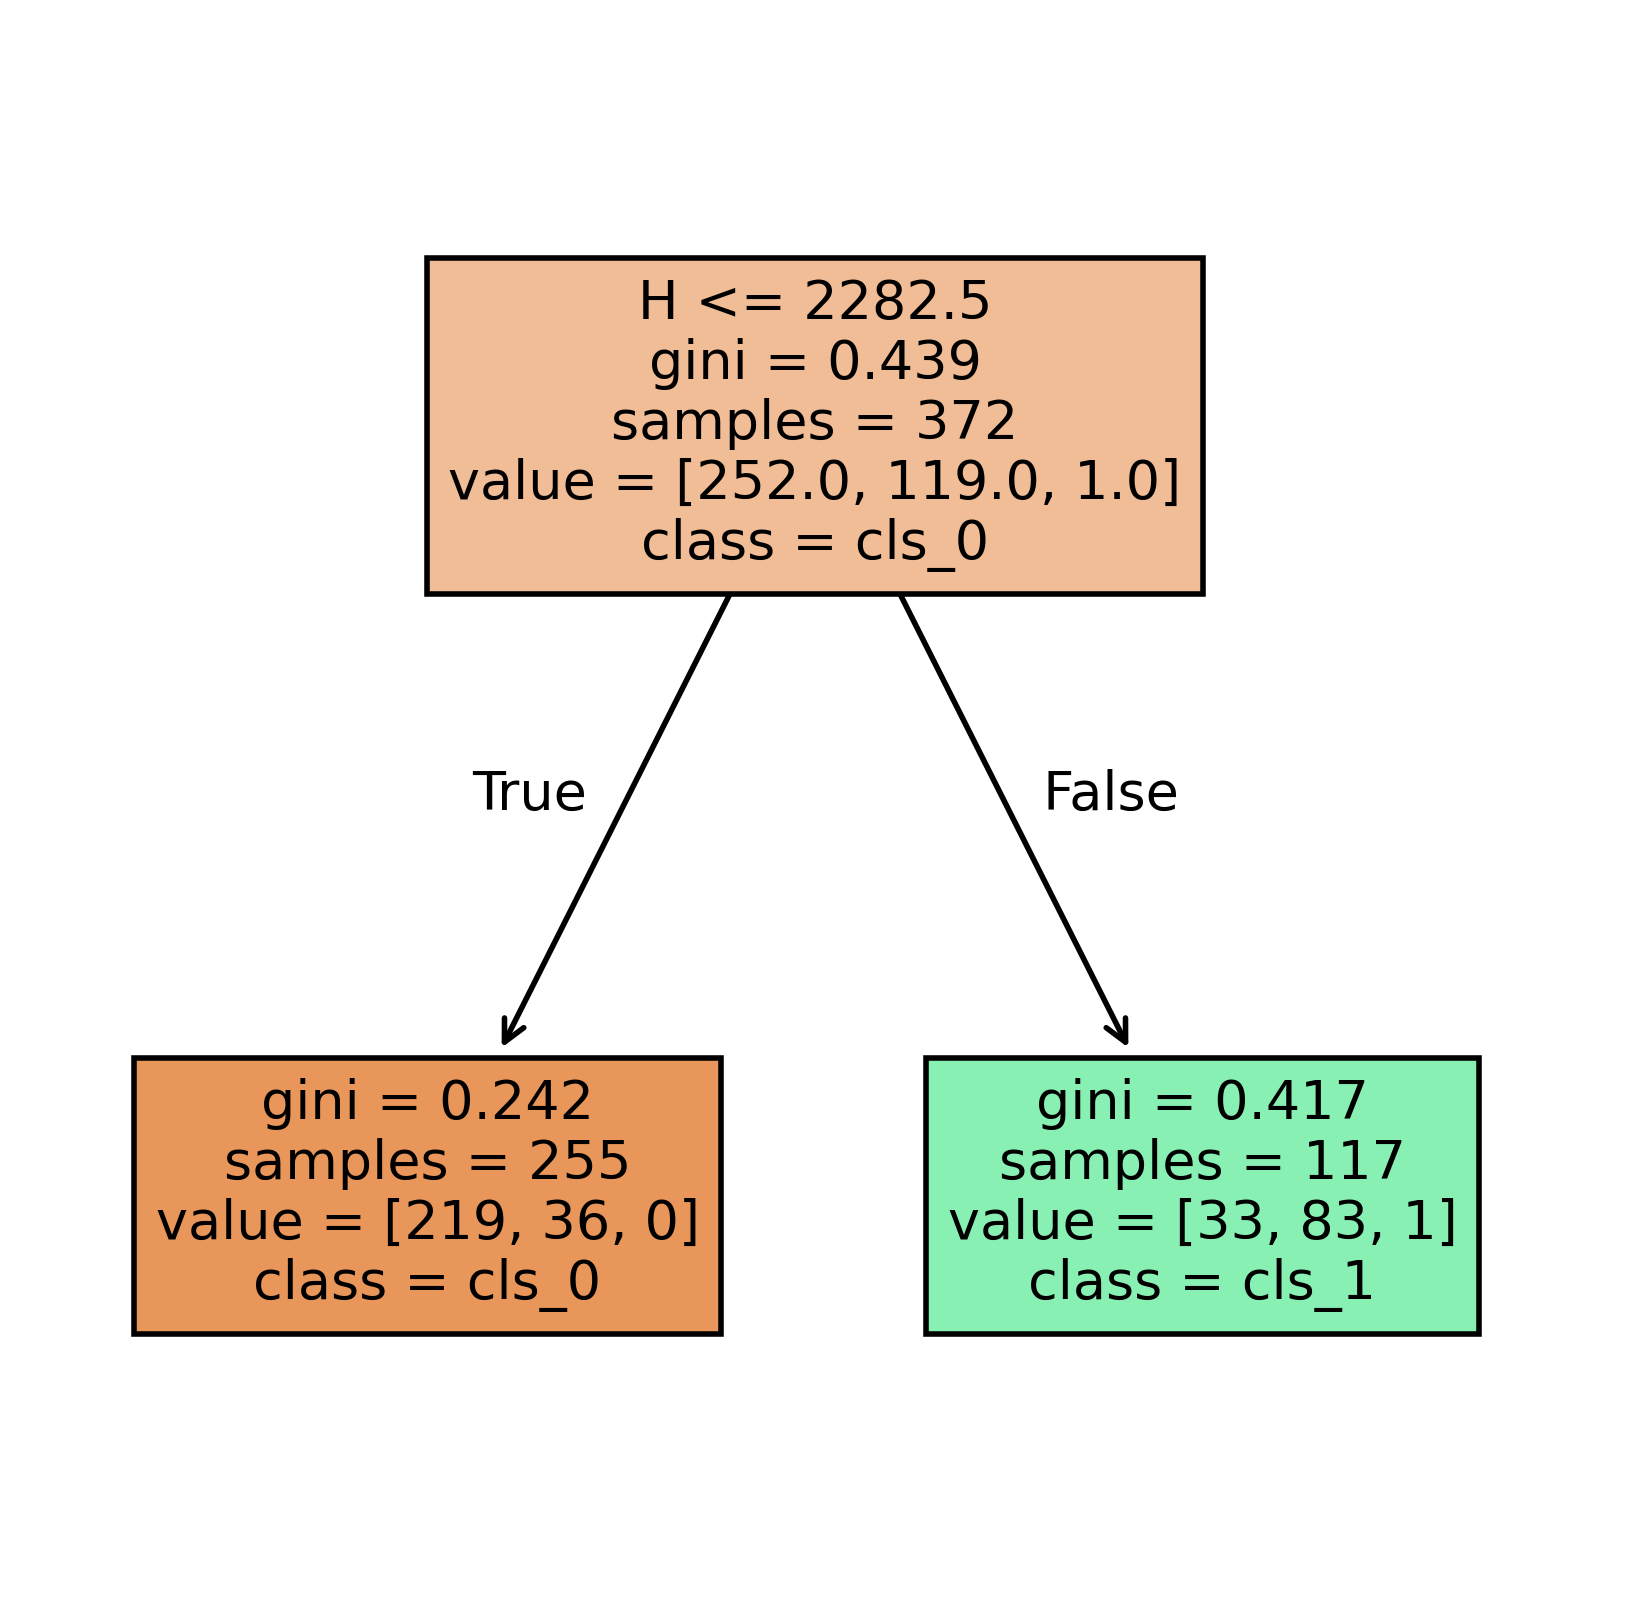

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5),dpi=400)
plot_tree(dtc2,feature_names=X.columns,class_names=['cls_0','cls_1'],filled=True)
plt.show()